Генерация данных

установка библиотеки для создания синтетических данных

In [ ]:
!pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Данные

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from tqdm import tqdm

np.random.seed(42)
random.seed(42)

Список популярных ФИО. Информация взята из открытых источников (например, википедия и статьи с анализом популярных фио)

In [ ]:
print("1. генерация клиентов")
n_clients = 35000

russian_last_names = [
    'Иванов', 'Петров', 'Сидоров', 'Смирнов', 'Кузнецов', 'Попов', 'Васильев',
    'Михайлов', 'Федоров', 'Морозов', 'Волков', 'Алексеев', 'Лебедев', 'Семенов',
    'Егоров', 'Павлов', 'Козлов', 'Степанов', 'Николаев', 'Орлов', 'Андреев',
    'Макаров', 'Никитин', 'Захаров', 'Зайцев', 'Соловьев', 'Борисов', 'Яковлев',
    'Григорьев', 'Романов', 'Воробьев', 'Сергеев', 'Бондарев', 'Крылов', 'Белов',
    'Гусев', 'Титов', 'Кузьмин', 'Баранов', 'Емельянов', 'Пономарев', 'Виноградов',
    'Быков', 'Сорокин', 'Беляев', 'Киселев', 'Леонтьев', 'Медведев', 'Тарасов',
    'Комаров', 'Жуков', 'Осипов', 'Кудрявцев', 'Новиков', 'Фомин', 'Максимов'
]

uzbek_last_names = [
    'Абдукаримов', 'Абдулин', 'Абдуллаев', 'Алимов', 'Алиханов', 'Аминов', 'Асадов',
    'Аскаров', 'Атаев', 'Ахмедов', 'Байдадаев', 'Бакиржонов', 'Бердиев', 'Бердыев',
    'Болтаев', 'Гафуров', 'Джафаров', 'Дустов', 'Ибрагимов', 'Исаков', 'Искандаров',
    'Искандеров', 'Йулдошев', 'Кадыров', 'Каримов', 'Каюмов', 'Мавлонов', 'Мамажонов',
    'Матмуродов', 'Матчанов', 'Махкамов', 'Махмудов', 'Мирзиёев', 'Мирзияев', 'Мурадов',
    'Мусабаев', 'Мусабеков', 'Мусаев', 'Мусаков', 'Мустафаев', 'Мухаммадиев', 'Наврузов',
    'Нарбаев', 'Насриддинов', 'Нишанов', 'Ниязбеков', 'Ниязов', 'Нуралиев', 'Нурматов',
    'Нурмухамедов', 'Раджабов', 'Раззаков', 'Рахимов', 'Рахманов', 'Рахмонов', 'Рашидов',
    'Ризаев', 'Рустамов', 'Сагдиев', 'Садыков', 'Саипов', 'Салихов', 'Саттаров',
    'Сафаров', 'Сулейманов', 'Султанов', 'Тажиев', 'Таиров', 'Умаров', 'Умурзаков',
    'Усманов', 'Усманходжаев', 'Хакимов', 'Хашимов', 'Худойбердыев', 'Шадыев', 'Шарипов',
    'Шодиев', 'Юлдашев', 'Юнусов', 'Якубов'
]

all_last_names = russian_last_names + uzbek_last_names

russian_male_names = [
    'Александр', 'Алексей', 'Анатолий', 'Андрей', 'Антон', 'Аркадий', 'Арсений', 'Артём',
    'Борис', 'Вадим', 'Валентин', 'Валерий', 'Василий', 'Виктор', 'Виталий', 'Владимир',
    'Владислав', 'Вячеслав', 'Геннадий', 'Георгий', 'Глеб', 'Григорий', 'Даниил', 'Денис',
    'Дмитрий', 'Евгений', 'Егор', 'Иван', 'Игорь', 'Илья', 'Кирилл', 'Константин',
    'Лев', 'Леонид', 'Максим', 'Марат', 'Матвей', 'Михаил', 'Никита', 'Николай',
    'Олег', 'Павел', 'Пётр', 'Роман', 'Руслан', 'Святослав', 'Семён', 'Сергей',
    'Станислав', 'Степан', 'Тарас', 'Тимофей', 'Тимур', 'Фёдор', 'Филипп', 'Эдуард',
    'Юрий', 'Ярослав'
]

russian_female_names = [
    'Александра', 'Алина', 'Алиса', 'Алла', 'Анастасия', 'Ангелина', 'Анна', 'Антонина',
    'Анфиса', 'Валентина', 'Валерия', 'Варвара', 'Василиса', 'Вера', 'Вероника', 'Виктория',
    'Галина', 'Дарья', 'Евгения', 'Екатерина', 'Елена', 'Елизавета', 'Жанна', 'Зинаида',
    'Зоя', 'Инна', 'Ирина', 'Карина', 'Кира', 'Клавдия', 'Кристина', 'Ксения',
    'Лариса', 'Лидия', 'Лилия', 'Любовь', 'Людмила', 'Маргарита', 'Марина', 'Мария',
    'Надежда', 'Наталья', 'Нина', 'Нонна', 'Оксана', 'Олеся', 'Ольга', 'Полина',
    'Раиса', 'Регина', 'Светлана', 'София', 'Таисия', 'Тамара', 'Татьяна', 'Ульяна',
    'Юлия', 'Яна'
]

uzbek_male_names = [
    'Ибрагим', 'Юсуф', 'Исмаил', 'Исхак', 'Якуб', 'Юнус', 'Мансур', 'Мухаммад',
    'Рашид', 'Расул', 'Рахим', 'Карим', 'Маджид', 'Умид', 'Хасан', 'Хусан',
    'Рустам', 'Фархад', 'Бахтияр', 'Пулат', 'Мурад', 'Орзу', 'Сурат', 'Шухрат',
    'Бахрам', 'Озод', 'Фарух', 'Шахрух', 'Фаррух', 'Анвар', 'Арслан', 'Арслон',
    'Батыр', 'Баходир', 'Килич', 'Саид', 'Санат', 'Темур', 'Тимур', 'Улугбек',
    'Элиор', 'Эльдар', 'Зафар', 'Ботир', 'Тохир', 'Искандар', 'Искандер', 'Бури',
    'Болта', 'Теша', 'Калкон', 'Ульмас', 'Турсун', 'Тургун', 'Тохта'
]

uzbek_female_names = [
    'Фатима', 'Зухра', 'Мухаббат', 'Аиша', 'Мадина', 'Ширин', 'Гульчехра', 'Гульнара',
    'Гулнора', 'Лола', 'Нилуфар', 'Алтынгуль', 'Олтингул', 'Ойдин', 'Адиба', 'Дилором',
    'Феруза', 'Наргиза', 'Мохдил', 'Райхон', 'Садокат', 'Шахноза', 'Дилноза', 'Малика',
    'Махлиё', 'Нодира', 'Сайёра', 'Умида', 'Хуршида', 'Ширин'
]

patronymics_male = [
    'Александрович', 'Алексеевич', 'Анатольевич', 'Андреевич', 'Антонович', 'Борисович',
    'Вадимович', 'Валентинович', 'Валерьевич', 'Васильевич', 'Викторович', 'Витальевич',
    'Владимирович', 'Владиславович', 'Вячеславович', 'Геннадьевич', 'Георгиевич', 'Григорьевич',
    'Данилович', 'Денисович', 'Дмитриевич', 'Евгеньевич', 'Егорович', 'Иванович',
    'Игоревич', 'Ильич', 'Кириллович', 'Константинович', 'Леонидович', 'Львович',
    'Максимович', 'Матвеевич', 'Михайлович', 'Никитич', 'Николаевич', 'Олегович',
    'Павлович', 'Петрович', 'Романович', 'Русланович', 'Семёнович', 'Сергеевич',
    'Станиславович', 'Степанович', 'Тимофеевич', 'Тимурович', 'Фёдорович', 'Филиппович',
    'Эдуардович', 'Юрьевич', 'Ярославович'
]

patronymics_female = [
    'Александровна', 'Алексеевна', 'Анатольевна', 'Андреевна', 'Антоновна', 'Борисовна',
    'Вадимовна', 'Валентиновна', 'Валерьевна', 'Васильевна', 'Викторовна', 'Витальевна',
    'Владимировна', 'Владиславовна', 'Вячеславовна', 'Геннадьевна', 'Георгиевна', 'Григорьевна',
    'Даниловна', 'Денисовна', 'Дмитриевна', 'Евгеньевна', 'Егоровна', 'Ивановна',
    'Игоревна', 'Ильинична', 'Кирилловна', 'Константиновна', 'Леонидовна', 'Львовна',
    'Максимовна', 'Матвеевна', 'Михайловна', 'Никитична', 'Николаевна', 'Олеговна',
    'Павловна', 'Петровна', 'Романовна', 'Руслановна', 'Семёновна', 'Сергеевна',
    'Станиславовна', 'Степановна', 'Тимофеевна', 'Тимуровна', 'Фёдоровна', 'Филипповна',
    'Эдуардовна', 'Юрьевна', 'Ярославовна'
]

1. генерация клиентов


генерация телефона

In [ ]:
def generate_phone():
    return f"+7{random.randint(900, 999)}{random.randint(1000000, 9999999)}"

def generate_email(fio, client_id=None):
    parts = fio.split()
    if len(parts) >= 2:
        last_name = parts[0].lower()
        first_name = parts[1].lower()
        translit_map = {
            'а': 'a', 'б': 'b', 'в': 'v', 'г': 'g', 'д': 'd', 'е': 'e', 'ё': 'e',
            'ж': 'zh', 'з': 'z', 'и': 'i', 'й': 'y', 'к': 'k', 'л': 'l', 'м': 'm',
            'н': 'n', 'о': 'o', 'п': 'p', 'р': 'r', 'с': 's', 'т': 't', 'у': 'u',
            'ф': 'f', 'х': 'kh', 'ц': 'ts', 'ч': 'ch', 'ш': 'sh', 'щ': 'shch',
            'ъ': '', 'ы': 'y', 'ь': '', 'э': 'e', 'ю': 'yu', 'я': 'ya'
        }
        last_name_trans = ''.join(translit_map.get(c, c) for c in last_name)
        first_name_trans = ''.join(translit_map.get(c, c) for c in first_name)
        domains = ['gmail.com', 'yandex.ru', 'mail.ru', 'bk.ru', 'inbox.ru']
        domain = random.choice(domains)
        if random.random() < 0.3:
            return f"{first_name_trans}.{last_name_trans}{random.randint(1, 999)}@{domain}"
        else:
            return f"{last_name_trans}{random.randint(1, 999)}@{domain}"
    else:
        return f"user{client_id or random.randint(1, 999999)}@{random.choice(['gmail.com', 'yandex.ru', 'mail.ru'])}"

генерация девайсов

In [ ]:
def generate_device():
    device_types = ['iPhone', 'Samsung Galaxy', 'Xiaomi', 'Huawei', 'PC Windows', 'MacBook', 'iPad', 'Android Tablet']
    device_type = random.choice(device_types)
    os_map = {
        'iPhone': 'iOS', 'Samsung Galaxy': 'Android', 'Xiaomi': 'Android', 'Huawei': 'Android',
        'PC Windows': 'Windows', 'MacBook': 'macOS', 'iPad': 'iOS', 'Android Tablet': 'Android'
    }
    return {
        'device_id': f"DEV_{random.randint(10000, 99999)}",
        'device_type': device_type,
        'os': os_map[device_type]
    }

просчет риск-скора

In [ ]:
def calculate_client_risk_score():
    base_risk = np.random.beta(2, 5)
    if random.random() < 0.05:
        base_risk = np.random.uniform(0.4, 0.8)
    if random.random() < 0.01:
        base_risk = np.random.uniform(0.7, 0.95)
    return round(base_risk, 3)

In [ ]:
def generate_fio():
    gender = random.choice(['male', 'female'])
    ethnicity = random.choices(['russian', 'uzbek'], weights=[0.7, 0.3])[0]
    if gender == 'male':
        if ethnicity == 'russian':
            first_name = random.choice(russian_male_names)
            patronymic = random.choice(patronymics_male)
        else:
            first_name = random.choice(uzbek_male_names)
            patronymic = random.choice(patronymics_male)
        last_name = random.choice(all_last_names)
    else:
        if ethnicity == 'russian':
            first_name = random.choice(russian_female_names)
            patronymic = random.choice(patronymics_female)
        else:
            first_name = random.choice(uzbek_female_names)
            patronymic = random.choice(patronymics_female)
        last_name = random.choice(all_last_names)
        if last_name.endswith('ов'):
            last_name = last_name[:-2] + 'ова'
        elif last_name.endswith('ев'):
            last_name = last_name[:-2] + 'ева'
        elif last_name.endswith('ин'):
            last_name = last_name[:-2] + 'ина'
    return f"{last_name} {first_name} {patronymic}"

clients_data = []
shared_phones_pool = [generate_phone() for _ in range(500)]
shared_emails_pool = [f"shared{random.randint(1, 999)}@{random.choice(['gmail.com', 'yandex.ru', 'mail.ru'])}" for _ in range(300)]
shared_devices_pool = [generate_device() for _ in range(200)]

shared_phones_usage = {phone: 0 for phone in shared_phones_pool}
shared_emails_usage = {email: 0 for email in shared_emails_pool}
shared_devices_usage = {dev['device_id']: 0 for dev in shared_devices_pool}

In [ ]:
for i in range(1, n_clients + 1):
    fio = generate_fio()
    accounts_count = np.random.poisson(2) + 1
    if accounts_count > 5:
        accounts_count = 5
    birth_year = random.randint(1940, 2002)
    if random.random() < 0.15:
        risk_score = None
    else:
        risk_score = calculate_client_risk_score()

    n_phones = random.randint(1, 3)
    phones = []
    use_shared_phone = random.random() < 0.1
    for p_idx in range(n_phones):
        if use_shared_phone and p_idx == 0 and shared_phones_pool:
            available_phones = [p for p in shared_phones_pool if shared_phones_usage[p] < 5]
            if available_phones:
                phone = random.choice(available_phones)
                shared_phones_usage[phone] += 1
                phones.append({'number': phone, 'type': random.choice(['mobile', 'home', 'work']), 'is_shared': True})
            else:
                phones.append({'number': generate_phone(), 'type': random.choice(['mobile', 'home', 'work']), 'is_shared': False})
        else:
            phones.append({'number': generate_phone(), 'type': random.choice(['mobile', 'home', 'work']), 'is_shared': False})

    n_emails = random.randint(1, 2)
    emails = []
    use_shared_email = random.random() < 0.08
    for e_idx in range(n_emails):
        if use_shared_email and e_idx == 0 and shared_emails_pool:
            available_emails = [e for e in shared_emails_pool if shared_emails_usage[e] < 3]
            if available_emails:
                email = random.choice(available_emails)
                shared_emails_usage[email] += 1
                emails.append({'address': email, 'domain': email.split('@')[1], 'is_shared': True})
            else:
                email = generate_email(fio, i)
                emails.append({'address': email, 'domain': email.split('@')[1], 'is_shared': False})
        else:
            email = generate_email(fio, i)
            emails.append({'address': email, 'domain': email.split('@')[1], 'is_shared': False})

    n_devices = random.randint(1, 4)
    devices = []
    use_shared_device = random.random() < 0.15
    for d_idx in range(n_devices):
        if use_shared_device and d_idx == 0 and shared_devices_pool:
            available_devices = [d for d in shared_devices_pool if shared_devices_usage[d['device_id']] < 4]
            if available_devices:
                device = random.choice(available_devices)
                shared_devices_usage[device['device_id']] += 1
                device_copy = device.copy()
                device_copy['is_shared'] = True
                devices.append(device_copy)
            else:
                device = generate_device()
                device['is_shared'] = False
                devices.append(device)
        else:
            device = generate_device()
            device['is_shared'] = False
            devices.append(device)

    clients_data.append({
        'client_id': i,
        'fio': fio,
        'birth_year': birth_year,
        'registration_region': random.choice(['Москва', 'СПб', 'МО', 'Регионы', 'СЗФО', 'ЮФО']),
        'client_tier': random.choices(['standard', 'premium', 'vip'], weights=[0.8, 0.15, 0.05])[0],
        'risk_score': risk_score,
        'accounts_count': accounts_count,
        'phones': phones,
        'emails': emails,
        'devices': devices
    })

clients_df = pd.DataFrame(clients_data)
print(f'сгенерировано клиентов: {len(clients_df)}')
print(f'клиентов с риск-скором: {clients_df['risk_score'].notna().sum()}')
print(f'новых клиентов (без риск-скора): {clients_df['risk_score'].isna().sum()}')

сгенерировано клиентов: 35000
клиентов с риск-скором: 29720
новых клиентов (без риск-скора): 5280


In [ ]:
print('генерация счетов')
accounts_data = []
account_id_counter = 1
account_types_ru = ['текущий', 'сберегательный', 'кредитный', 'депозитный', 'зарплатный']
account_weights = [0.5, 0.2, 0.15, 0.1, 0.05]

генерация счетов


In [ ]:
for _, client in clients_df.iterrows():
    client_id = client['client_id']
    n_accounts = client['accounts_count']
    for acc_idx in range(n_accounts):
        account_type = random.choices(account_types_ru, weights=account_weights)[0]
        days_ago = random.randint(1, 1095)
        open_date = (datetime.now() - timedelta(days=days_ago)).strftime('%Y-%m-%d')
        if account_type == 'кредитный':
            balance = round(random.uniform(-500000, 100000), 2)
        else:
            balance = round(np.random.lognormal(10, 2), 2)
            if balance > 5000000:
                balance = 5000000
        account_status = random.choices(
            ['активен', 'заблокирован', 'мониторинг', 'неактивен'],
            weights=[0.85, 0.03, 0.02, 0.1]
        )[0]
        accounts_data.append({
            'account_id': f'ACC_{account_id_counter:08d}',
            'client_id': client_id,
            'account_number': f'40817{random.randint(1000000, 9999999)}',
            'account_type': account_type,
            'open_date': open_date,
            'balance': round(balance, 2),
            'currency': random.choices(['RUB', 'USD', 'EUR'], weights=[0.9, 0.07, 0.03])[0],
            'status': account_status,
            'risk_score': None
        })
        account_id_counter += 1

accounts_df = pd.DataFrame(accounts_data)
print(f'сгенерировано счетов: {len(accounts_df)}')

сгенерировано счетов: 102679


In [ ]:
print('3.генерация компаний')
n_companies = 15000

def calculate_company_risk_score():
    base_risk = np.random.beta(3, 7)
    if random.random() < 0.05:
        base_risk = np.random.uniform(0.5, 0.9)
    return round(base_risk, 3)

3.генерация компаний


In [ ]:
activities_ru = {
    'Торговля': {'weight': 0.245, 'risk_mod': 0.0},
    'Строительство': {'weight': 0.119, 'risk_mod': 0.05},
    'Недвижимость': {'weight': 0.094, 'risk_mod': 0.1},
    'Консалтинг и наука': {'weight': 0.082, 'risk_mod': -0.02},
    'Производство': {'weight': 0.08, 'risk_mod': 0.0},
    'Транспорт и логистика': {'weight': 0.063, 'risk_mod': 0.02},
    'Финансовые услуги': {'weight': 0.05, 'risk_mod': 0.15},
    'IT и технологии': {'weight': 0.04, 'risk_mod': -0.05},
    'Продукты питания': {'weight': 0.035, 'risk_mod': -0.03},
    'Развлечения': {'weight': 0.025, 'risk_mod': 0.02},
    'Образование': {'weight': 0.02, 'risk_mod': -0.04},
    'Медицина': {'weight': 0.018, 'risk_mod': -0.02},
    'Крипто-обменники': {'weight': 0.005, 'risk_mod': 0.35},
    'Прочее': {'weight': 0.123, 'risk_mod': 0.1}
}

activity_list_ru = []
activity_weights_ru = []
risk_mods_ru = []

for activity, params in activities_ru.items():
    activity_list_ru.append(activity)
    activity_weights_ru.append(params['weight'])
    risk_mods_ru.append(params['risk_mod'])

activity_weights_ru = np.array(activity_weights_ru) / sum(activity_weights_ru)

In [ ]:
company_names_by_activity = {
    'Торговля': [
        'Магнит', 'Пятерочка', 'Перекресток', 'Дикси', 'Ашан', 'Лента', 'Ozon', 'Wildberries',
        'Lamoda', 'М.Видео', 'Эльдорадо', 'DNS', 'Ситилинк', 'Детский мир', 'Спортмастер',
        'Леруа Мерлен', 'ИКЕА', 'Castorama', 'METRO', 'Глобус', 'Атак', 'ВкусВилл', 'Азбука вкуса',
        'Золотое яблоко', 'Рив Гош', "Л'Этуаль", 'Снежная Королева', 'Kari', 'Zenden',
        'Твой дом', 'Hoff', 'ВсеИнструменты.ру', 'Петрович', 'Самокат', 'Яндекс.Лавка'
    ],
    'Строительство': [
        'ПИК', 'Эталон', 'ЛСР', 'Группа ЛСР', 'Донстрой', 'Инград', 'Самолет', 'ФСК', 'MR Group',
        'А101', 'Страна Девелопмент', 'Брусника', 'ЮИТ', 'NCC', 'Лемминкяйнен', 'Балтийская жемчужина',
        'Моспроект-2', 'Мосинжпроект', 'Стройгазмонтаж', 'Стройтрансгаз', 'Ренова-СтройГруп',
        'Главстрой-СПб', 'Setl Group', 'ЦДС', 'КВС', 'Арсенал-Недвижимость', 'Сенатор'
    ],
    'Недвижимость': [
        'МИЭЛЬ', 'ИНКОМ-Недвижимость', 'Этажи', 'Циан', 'Авито Недвижимость', 'БЕСТ-Недвижимость',
        'Century 21', 'Remax', 'Миэль-Аренда', 'НДВ-Недвижимость', 'Бон Тон', 'Knight Frank',
        'CBRE', 'JLL', 'Colliers International', 'Cushman & Wakefield', 'Магазин квартир',
        'Агентство.ру', 'Росриэлт', 'Мирарт', 'Петрополь', 'Трест'
    ],
    'Консалтинг и наука': [
        'PwC', 'Deloitte', 'EY', 'KPMG', 'BCG', 'McKinsey', 'Strategy Partners', 'Яков и партнеры',
        'Технологии Доверия', 'Kept', 'SBS Consulting', 'НЭО Центр', 'ФБК', '2K', 'Росэкспертиза',
        'РАНХиГС', 'ВШЭ', 'Сколково', 'Иннопрактика', 'Курчатовский институт'
    ],
    'Производство': [
        'Газпром', 'Роснефть', 'Лукойл', 'Сургутнефтегаз', 'Татнефть', 'НОВАТЭК', 'Сибур',
        'Русал', 'Норникель', 'Северсталь', 'ММК', 'НЛМК', 'Металлоинвест', 'Евраз', 'Уралкалий',
        'Фосагро', 'Акрон', 'СИБУР Холдинг', 'Тольяттиазот', 'Казаньоргсинтез', 'Нижнекамскнефтехим',
        'Омский каучук', 'Уфаоргсинтез', 'АвтоВАЗ', 'КамАЗ', 'ГАЗ', 'УАЗ', 'Соллерс', 'Рено Россия',
        'Hyundai Motor Manufacturing Rus', 'Toyota Motor Manufacturing Russia', 'Ford Sollers',
        'Балтика', 'Объединенные Пивоварни', 'AB InBev Efes', 'Coca-Cola HBC Россия',
        'PepsiCo Россия', 'Danone Россия', 'Nestle Россия', 'Марс', 'КДВ Групп', 'Черкизово',
        'Мираторг', 'Русагро', 'Эфко', 'Содружество', 'Астон', 'Балтика', 'Очаково'
    ],
    'Транспорт и логистика': [
        'РЖД', 'Аэрофлот', 'S7 Airlines', 'Utair', 'Уральские авиалинии', 'Победа', 'Россия',
        'Nordwind Airlines', 'Red Wings', 'Трансаэро', 'FESCO', 'ДВМП', 'Совкомфлот', 'Новошип',
        'Волга-Днепр', 'Почта России', 'DPD', 'CDEK', 'DHL Express', 'FedEx', 'UPS',
        'Pony Express', 'ЖелДорЭкспедиция', 'Деловые линии', 'ПЭК', 'Байкал Сервис', 'Грузовичкоф',
        'Яндекс.Доставка', 'СберЛогистика', 'Ozon Логистика', 'Wildberries Логистика'
    ],
    'Финансовые услуги': [
        'Сбербанк', 'ВТБ', 'Газпромбанк', 'Альфа-Банк', 'Россельхозбанк', 'Московский кредитный банк',
        'Банк Открытие', 'Совкомбанк', 'Райффайзенбанк', 'ЮниКредит Банк', 'Росбанк', 'Тинькофф Банк',
        'Промсвязьбанк', 'Банк ДОМ.РФ', 'Абсолют Банк', 'Уралсиб', 'Ак Барс Банк', 'Банк Санкт-Петербург',
        'Киви Банк', 'ОТП Банк', 'Хоум Кредит Банк', 'Ренессанс Кредит', 'Банк Русский Стандарт',
        'Московская биржа', 'СПБ Биржа', 'Ингосстрах', 'РЕСО-Гарантия', 'СОГАЗ', 'АльфаСтрахование',
        'ВСК', 'Росгосстрах', 'Сбербанк Страхование', 'Тинькофф Страхование'
    ],
    'IT и технологии': [
        'Яндекс', 'VK', 'Ozon Tech', 'СберТех', 'Тинькофф', 'Wildberries Тех', 'Avito', 'Циан',
        '2ГИС', 'Лаборатория Касперского', 'ABBYY', 'Acronis', 'Parallels', 'JetBrains', 'EPAM',
        'Luxoft', 'IBS', 'КРОК', 'Техносерв', 'ЛАНИТ', 'Softline', 'Merlion', '1С', 'Галактика',
        'Диасофт', 'Бизнес Автоматика', 'Элвис-Плюс', 'Новые облачные технологии', 'МойОфис',
        'Р7-Офис', 'Астра-Софт', 'Ред Софт', 'Базальт СПО', 'Positive Technologies', 'InfoWatch',
        'Solar Security', 'Код Безопасности', 'Аладдин Р.Д.', 'Крипто-Про', 'VK Cloud Solutions',
        'Yandex Cloud', 'SberCloud', 'Selectel', 'РТЛабс', 'Ростелеком Информационные Технологии'
    ],
    'Продукты питания': [
        'Черкизово', 'Мираторг', 'Русагро', 'Эфко', 'Содружество', 'Астон', 'Балтика', 'Объединенные Пивоварни',
        'AB InBev Efes', 'Coca-Cola HBC Россия', 'PepsiCo Россия', 'Danone Россия', 'Nestle Россия',
        'Марс', 'КДВ Групп', 'Хлебный Дом', 'Каравай', 'Фацер', 'Коломенское', 'Золотой колос',
        'Вимм-Билль-Данн', 'Мултон', 'Лебедянский', 'Нидан', 'Сады Придонья', 'Боржоми', 'Исток',
        'Чистая линия', 'Талосто', 'Юнимилк', 'Петмол', 'Галактика', 'Простоквашино', 'Домик в деревне',
        'Валио', 'Хохланд', 'President', 'Б.Ю. Александров', 'Конти-Рус', 'Славянка', 'Большевик'
    ],
    'Развлечения': [
        'Okko', 'Кинопоиск', 'Иви', 'Start', 'Premier', 'Wink', 'More.tv', 'НТВ-Плюс', 'Триколор ТВ',
        'Мосфильм', 'Ленфильм', 'СТВ', 'Централ Партнершип', 'Каро Фильм', 'Синема Парк', 'Формула Кино',
        'Киномакс', 'Люксор', 'Каро', 'Буше', 'Космопоиск', 'Москонцерт', 'Русский Стандарт Казино'
    ],
    'Образование': [
        'Нетология', 'Skillbox', 'GeekBrains', 'Skyeng', 'Учи.ру', 'Фоксфорд', 'Maximum Education',
        'Тетрика', 'Яндекс.Практикум', 'СберКласс', 'МГУ', 'СПбГУ', 'ВШЭ', 'МФТИ', 'МГТУ им. Баумана',
        'ИТМО', 'УрФУ', 'КФУ', 'НГУ', 'ТГУ', 'ДВФУ', 'РАНХиГС', 'Финансовый университет', 'РЭУ им. Плеханова'
    ],
    'Медицина': [
        'Инвитро', 'Гемотест', 'Хеликс', 'СИТИЛАБ', 'KDL', 'Европейский Медицинский Центр', 'Медси',
        'Семейный доктор', 'Будь Здоров', 'Мать и дитя', 'Скандинавский центр здоровья', 'АВС-медицина',
        'СМ-Клиника', 'Мединвестгрупп', 'Клиника №1', 'Ниармедик', 'Он Клиник', 'Медицина', 'ЦЭЛТ',
        'ФНКЦ ФМБА', 'НМИЦ онкологии им. Блохина', 'НМИЦ им. Алмазова', 'НИИ Склифосовского',
        'Боткинская больница', 'Сеченовский университет', 'Пироговский центр'
    ],
    'Крипто-обменники': [
        'BestChange', 'CoinList', 'Binance RU', 'CommEX', 'Garantex', 'Криптокафе', 'Криптообменник.ру',
        '24PayBank', 'Matbea', 'Kassa.cc', 'Fly Exchangers', 'Kupit-crypto.ru', 'Prostocash'
    ],
    'Прочее': [
        'Ростелеком', 'МТС', 'Мегафон', 'Билайн', 'Tele2', 'Yota', 'Роскосмос', 'Росатом', 'РусГидро',
        'Интер РАО', 'Мосэнерго', 'Петербургская сбытовая компания', 'Т Плюс', 'Квадра', 'Фортум',
        'Энел Россия', 'Юнипро', 'ОГК-2', 'ТГК-1', 'ТГК-2', 'МОЭК', 'Мосводоканал', 'Петербургводоканал',
        'Российские сети', 'ФСК ЕЭС', 'СО ЕЭС', 'Транснефть', 'Транснефтепродукт', 'Газпром нефть',
        'Славнефть', 'Башнефть', 'РуссНефть', 'НК Альянс', 'Нефтиса', 'Иркутская нефтяная компания'
    ]
}

In [ ]:
small_business_suffixes = ['ИП', 'ООО', 'ЗАО', 'ОА']
small_business_names = []
for i in range(5000):
    suffix = random.choice(small_business_suffixes)
    if suffix == 'ИП':
        name = f"{suffix} {random.choice(all_last_names)}"
    else:
        business_type = random.choice(['Трейд', 'Сервис', 'Логистик', 'Плюс', 'Групп', 'Инвест', 'Консалт', 'Строй', 'Торг', 'Пром'])
        prefix = random.choice(['Альфа', 'Бета', 'Гамма', 'Дельта', 'Омега', 'Сигма', 'Вега', 'Норд', 'Юг', 'Восток', 'Запад',
                               'Север', 'Центр', 'Регион', 'Стандарт', 'Оптима', 'Профи', 'Мастер', 'Эксперт', 'Лидер', 'Капитал'])
        name = f"{suffix} '{prefix} {business_type}'"
    small_business_names.append(name)

In [ ]:
def generate_company_name(activity, activity_dict):
    if random.random() < 0.3:
        return random.choice(small_business_names)
    if activity in activity_dict and activity_dict[activity]:
        return random.choice(activity_dict[activity])
    else:
        suffixes = ['Групп', 'Трейд', 'Сервис', 'Логистик', 'Плюс', 'Инвест', 'Консалт']
        return f"{activity} {random.choice(suffixes)}"

companies_data = []

In [ ]:
for i in tqdm(range(n_companies), desc="генерация компаний"):
    company_id = f'COMP_{i+1:05d}'
    activity_idx = np.random.choice(len(activity_list_ru), p=activity_weights_ru)
    activity_rus = activity_list_ru[activity_idx]
    risk_mod = risk_mods_ru[activity_idx]
    name = generate_company_name(activity_rus, company_names_by_activity)
    if random.random() < 0.2:
        risk_score = None
    else:
        risk_score = calculate_company_risk_score()
        risk_score = min(1.0, max(0.0, risk_score + risk_mod))
    inn_region = random.choice(['77', '78', '50', '23', '16', '66', '01', '02', '03', '04', '05', '06',
                                '07', '08', '09', '10', '11', '12', '13', '14', '15', '17', '18', '19'])
    inn = inn_region + ''.join([str(random.randint(0, 9)) for _ in range(10)])
    ogrn_type = random.choice([1, 5])
    ogrn = str(ogrn_type) + ''.join([str(random.randint(0, 9)) for _ in range(12)])
    owner_id = random.choice(clients_df['client_id']) if random.random() < 0.15 else None
    days_ago = random.randint(30, 5000)
    reg_date = (datetime.now() - timedelta(days=days_ago)).strftime('%Y-%m-%d')
    companies_data.append({
        'company_id': company_id,
        'name': name,
        'activity_code': activity_rus,
        'activity_name': activity_rus,
        'inn': inn,
        'ogrn': ogrn,
        'owner_id': owner_id,
        'risk_score': risk_score,
        'registration_date': reg_date
    })

генерация компаний: 100%|██████████| 15000/15000 [00:04<00:00, 3151.58it/s]


In [ ]:
companies_df = pd.DataFrame(companies_data)
print(f'сгенерировано компаний: {len(companies_df)}')
print(f'компаний с риск-скором: {companies_df['risk_score'].notna().sum()}')
print(f'новых компаний (без риск-скора): {companies_df['risk_score'].isna().sum()}')

сгенерировано компаний: 15000
компаний с риск-скором: 12089
новых компаний (без риск-скора): 2911


In [ ]:
print('4.расчет средних риск-скоров и заполнение пропусков')

avg_client_risk = clients_df['risk_score'].mean()
print(f'средний риск-скор клиентов (по существующим): {avg_client_risk:.3f}')

clients_df['risk_score'] = clients_df['risk_score'].fillna(avg_client_risk)
clients_df['risk_score'] = clients_df['risk_score'].round(3)

avg_company_risk = companies_df['risk_score'].mean()
print(f'средний риск-скор компаний (по существующим): {avg_company_risk:.3f}')

companies_df['risk_score'] = companies_df['risk_score'].fillna(avg_company_risk)
companies_df['risk_score'] = companies_df['risk_score'].round(3)

4.расчет средних риск-скоров и заполнение пропусков
средний риск-скор клиентов (по существующим): 0.307
средний риск-скор компаний (по существующим): 0.355


согласно указанным rulse-based метрикам обновляем рсик-скоры

In [ ]:
print('5. обновление риск-скоров счетов')

client_updated_risk = dict(zip(clients_df['client_id'], clients_df['risk_score']))

accounts_df['risk_score'] = accounts_df['client_id'].map(client_updated_risk)

for idx, row in accounts_df.iterrows():
    base_risk = row['risk_score']
    days_ago = (datetime.now() - datetime.strptime(row['open_date'], '%Y-%m-%d')).days
    if days_ago < 30:
        base_risk = min(1.0, base_risk + 0.1)
    if row['balance'] < -300000:
        base_risk = min(1.0, base_risk + 0.15)
    if row['status'] == 'мониторинг':
        base_risk = min(1.0, base_risk + 0.2)
    elif row['status'] == 'заблокирован':
        base_risk = min(1.0, base_risk + 0.3)
    accounts_df.at[idx, 'risk_score'] = round(base_risk, 3)

print(f'счетов с обновленным риск-скором: {len(accounts_df)}')
print(f'средний риск-скор счетов после обновления: {accounts_df['risk_score'].mean():.3f}')

5. обновление риск-скоров счетов
счетов с обновленным риск-скором: 102679
средний риск-скор счетов после обновления: 0.330


In [ ]:
print('6. генерация транзакций')
client_ids = clients_df['client_id'].tolist()
company_ids = companies_df['company_id'].tolist()

client_risk = dict(zip(clients_df['client_id'], clients_df['risk_score']))
account_risk = dict(zip(accounts_df['account_id'], accounts_df['risk_score']))
company_risk = dict(zip(companies_df['company_id'], companies_df['risk_score']))

client_accounts = accounts_df.groupby('client_id')['account_id'].apply(list).to_dict()

n_transactions = 600000
batch_size = 50000
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31, 23, 59, 59)

def is_fraudulent_transaction(row):
    fraud_score = 0
    if row['amount'] > 50000 and row['amount'] < 500000:
        fraud_score += 0.3
    elif row['amount'] >= 500000:
        fraud_score += 0.7
    hour = row['tx_date'].hour
    if 2 <= hour <= 5:
        fraud_score += 0.3
    if row.get('frequency_24h', 0) > 15:
        fraud_score += 0.3
    if row.get('frequency_24h', 0) > 30:
        fraud_score += 0.4
    if str(row['to_id']).startswith('UNKNOWN'):
        fraud_score += 0.5
    if str(row['to_id']).startswith('COMP') and row['to_risk'] > 0.6:
        fraud_score += 0.4
    if row['from_risk'] > 0.7:
        fraud_score += 0.3
    if int(row['amount'] * 100) % 1000 in [999, 111, 777]:
        fraud_score += 0.2
    if row.get('from_client') == row.get('to_client') and row['from_client'] is not None:
        fraud_score -= 0.2
    is_fraud = fraud_score > 0.6
    return is_fraud, fraud_score
transactions_data = []
fraud_count = 0

for batch_idx in tqdm(range(0, n_transactions // batch_size + 1), desc='генерация батчей'):
    batch_start = batch_idx * batch_size
    batch_end = min((batch_idx + 1) * batch_size, n_transactions)
    if batch_start >= n_transactions:
        break
    for i in range(batch_start, batch_end):
        from_client = random.choice(client_ids)
        from_accounts = client_accounts.get(from_client, [])
        if not from_accounts:
            continue
        from_account = random.choice(from_accounts)
        to_type = random.choices(['client', 'company', 'unknown'], weights=[0.65, 0.3, 0.05])[0]
        if to_type == 'client':
            to_client = random.choice(client_ids)
            to_accounts = client_accounts.get(to_client, [])
            if not to_accounts:
                continue
            to_account = random.choice(to_accounts)
            to_id = to_account
            to_risk = account_risk.get(to_account, 0.3)
        elif to_type == 'company':
            to_company = random.choice(company_ids)
            to_id = to_company
            to_risk = company_risk.get(to_company, 0.3)
        else:
            to_id = f'UNKNOWN_{random.randint(1, 1000)}'
            to_risk = random.uniform(0.5, 0.9)
        if to_type == 'company':
            if any(x in str(to_id) for x in ['Магнит', 'Пятерочка']):
                amount = round(random.uniform(100, 5000), 2)
            else:
                amount = round(np.random.lognormal(7, 1.8), 2)
        elif to_type == 'client':
            amount = round(np.random.lognormal(8, 2), 2)
        else:
            if random.random() < 0.3:
                amount = round(random.uniform(1000, 15000), 2)
            else:
                amount = round(random.uniform(100, 900), 2)
        if amount > 2000000:
            amount = round(random.uniform(1000, 500000), 2)
        tx_date = start_date + timedelta(seconds=random.randint(0, int((end_date - start_date).total_seconds())))
        if to_type == 'company':
            tx_type = 'оплата'
        elif to_type == 'client':
            tx_type = 'перевод'
        else:
            tx_type = 'неизвестно'
        frequency_24h = max(1, int(np.random.poisson(3)))
        if to_type == 'unknown':
            frequency_24h = max(5, int(np.random.poisson(10)))
        from_risk = client_risk.get(from_client, 0.3)
        to_client_local = to_client if to_type == 'client' else None
        fraud_check_data = {
            'amount': amount,
            'tx_date': tx_date,
            'frequency_24h': frequency_24h,
            'to_id': to_id,
            'to_risk': to_risk,
            'from_risk': from_risk,
            'from_client': from_client,
            'to_client': to_client_local
        }
        is_fraud, fraud_score = is_fraudulent_transaction(fraud_check_data)
        if is_fraud:
            fraud_count += 1
        sender = clients_df[clients_df['client_id'] == from_client].iloc[0]
        sender_phones = [p['number'] for p in sender['phones']]
        sender_emails = [e['address'] for e in sender['emails']]
        sender_devices = [d['device_id'] for d in sender['devices']]
        tx_record = {
            'transaction_id': f'TX_{batch_start + i:08d}',
            'from_client_id': from_client,
            'from_account_id': from_account,
            'to_id': to_id,
            'to_type': to_type,
            'transaction_type': tx_type,
            'amount': amount,
            'tx_datetime': tx_date.strftime('%Y-%m-%d %H:%M:%S'),
            'tx_hour': tx_date.hour,
            'tx_day_of_week': tx_date.weekday(),
            'frequency_24h': frequency_24h,
            'is_fraud': int(is_fraud),
            'fraud_score': round(fraud_score, 3),
            'status': random.choices(['завершена', 'заблокирована', 'помечена'], weights=[0.92, 0.03, 0.05])[0],
            'sender_phone': random.choice(sender_phones) if sender_phones else None,
            'sender_email': random.choice(sender_emails) if sender_emails else None,
            'sender_device': random.choice(sender_devices) if sender_devices else None
        }
        transactions_data.append(tx_record)
        if (i + 1) % 100000 == 0:
            print(f'сгенерировано {i + 1} транзакций')

6. генерация транзакций


генерация батчей:  15%|█▌        | 2/13 [01:47<09:41, 52.86s/it]

сгенерировано 100000 транзакций


генерация батчей:  31%|███       | 4/13 [02:45<05:34, 37.14s/it]

сгенерировано 200000 транзакций


...

сгенерировано 400000 транзакций


генерация батчей:  77%|███████▋  | 10/13 [05:40<01:29, 29.69s/it]

сгенерировано 500000 транзакций


генерация батчей:  92%|█████████▏| 12/13 [06:37<00:33, 33.13s/it]

сгенерировано 600000 транзакций


In [ ]:
transactions_df = pd.DataFrame(transactions_data)
print(f'сгенерировано транзакций: {len(transactions_df):,}')
print(f"мошеннических транзакций: {transactions_df['is_fraud'].sum():,} ({transactions_df['is_fraud'].mean()*100:.2f}%)")

сгенерировано транзакций: 600,000
мошеннических транзакций: 11,670 (1.94%)


Сохранение данных + utf-8

In [ ]:
clients_df['phones'] = clients_df['phones'].apply(lambda x: str(x) if isinstance(x, list) else x)
clients_df['emails'] = clients_df['emails'].apply(lambda x: str(x) if isinstance(x, list) else x)
clients_df['devices'] = clients_df['devices'].apply(lambda x: str(x) if isinstance(x, list) else x)

clients_df.to_csv('clients.csv', index=False, encoding='utf-8')
accounts_df.to_csv('accounts.csv', index=False, encoding='utf-8')
companies_df.to_csv('companies.csv', index=False, encoding='utf-8')
transactions_df.to_csv('transactions.csv', index=False, encoding='utf-8')

In [ ]:
print(f"клиенты: {len(clients_df):,}")
print(f"счета: {len(accounts_df):,}")
print(f"компании: {len(companies_df):,}")
print(f"транзакции: {len(transactions_df):,}")
print(f"мошеннические транзакции: {transactions_df['is_fraud'].sum():,} ({transactions_df['is_fraud'].mean()*100:.2f}%)")

клиенты: 35,000
счета: 102,679
компании: 15,000
транзакции: 600,000
мошеннические транзакции: 11,670 (1.94%)


Диаграмма

установка библиотек

In [ ]:
!apt-get install graphviz -qq
!pip install graphviz -qq

Use Case диаграмма

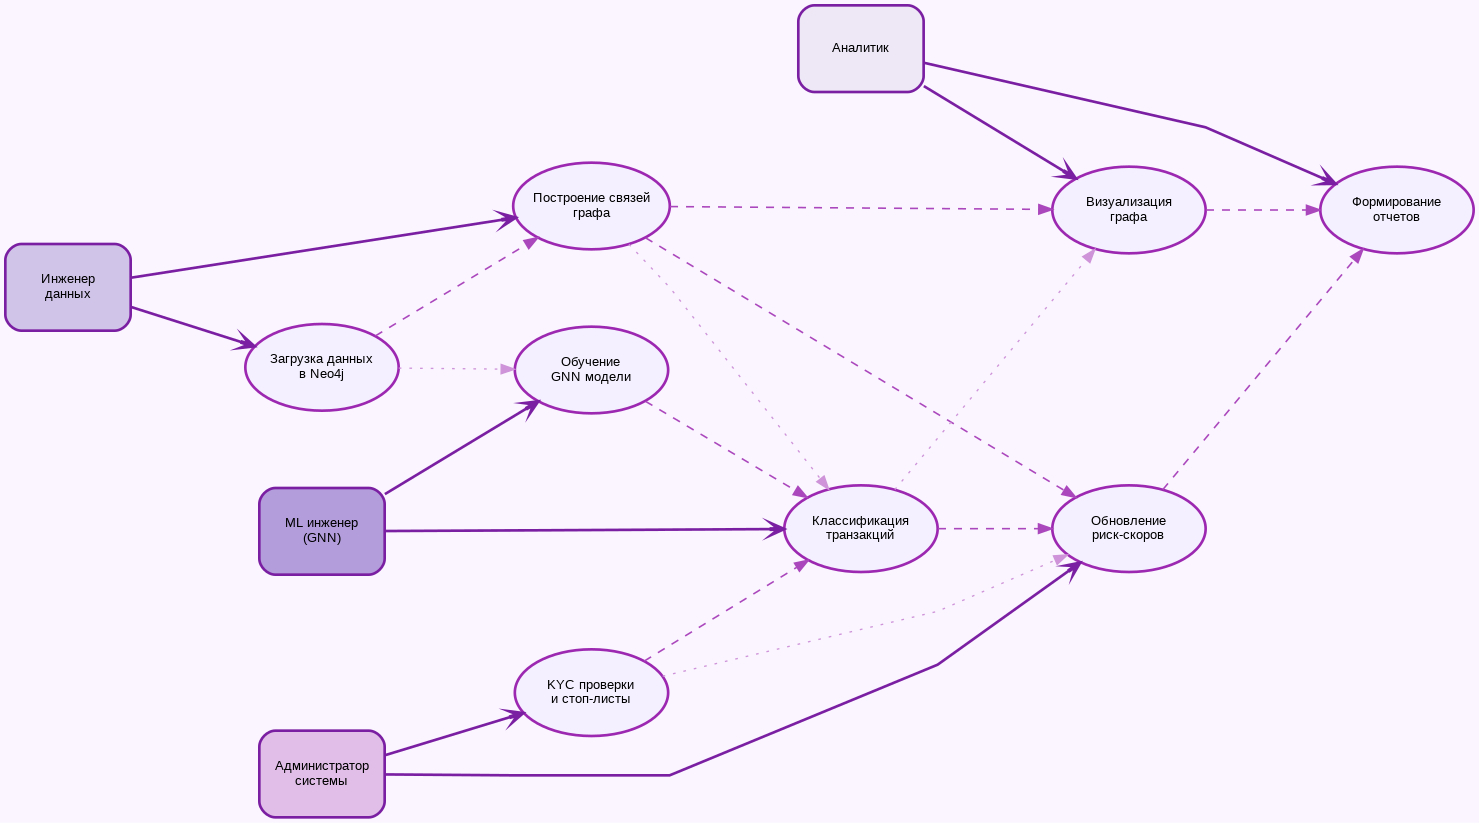

Use Case сохранена как usecase_simple.png


In [ ]:
import graphviz

dot = graphviz.Digraph('Система обнаружения мошенничества')
dot.attr(rankdir='LR', size='22,14', fontname='Helvetica', bgcolor='#faf5ff',
         splines='polyline', nodesep='0.8', ranksep='1.2')

dot.attr('node', fontname='Helvetica', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='8')

# сущности - слева
actors = {
    'A1': ('Аналитик', '#ede7f6'),
    'DE': ('Инженер\nданных', '#d1c4e9'),
    'ML': ('ML инженер\n(GNN)', '#b39ddb'),
    'Admin': ('Администратор\nсистемы', '#e1bee7')
}

for id_, (label, color) in actors.items():
    dot.node(id_, label, shape='box', style='rounded,filled', fillcolor=color,
             color='#7b1fa2', penwidth='2', width='1.3', height='0.9')

# прецеденты - кружочки
cases = {
    'UC1': 'Загрузка данных\nв Neo4j',
    'UC2': 'Построение связей\nграфа',
    'UC3': 'Обучение\nGNN модели',
    'UC4': 'Классификация\nтранзакций',
    'UC5': 'Визуализация\nграфа',
    'UC6': 'KYC проверки\nи стоп-листы',
    'UC7': 'Обновление\nриск-скоров',
    'UC8': 'Формирование\nотчетов'
}

for id_, label in cases.items():
    dot.node(id_, label, shape='ellipse', style='filled', fillcolor='#f5f0ff',
             color='#9c27b0', penwidth='2', width='1.6', height='0.9')

# связи актор -> прецедент (каждый актор соединен с несколькими)
dot.edge('A1', 'UC5', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('A1', 'UC8', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('DE', 'UC1', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('DE', 'UC2', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('ML', 'UC3', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('ML', 'UC4', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('Admin', 'UC6', penwidth='2', color='#7b1fa2', arrowhead='open')
dot.edge('Admin', 'UC7', penwidth='2', color='#7b1fa2', arrowhead='open')

# связи между прецедентами (каждый с каждым)
dot.edge('UC1', 'UC2', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC2', 'UC5', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC2', 'UC7', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC3', 'UC4', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC4', 'UC7', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC5', 'UC8', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC6', 'UC4', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')
dot.edge('UC7', 'UC8', style='dashed', color='#ab47bc', penwidth='1.2', xlabel='')

# доп связи
dot.edge('UC1', 'UC3', style='dotted', color='#ce93d8', penwidth='1')
dot.edge('UC2', 'UC4', style='dotted', color='#ce93d8', penwidth='1')
dot.edge('UC4', 'UC5', style='dotted', color='#ce93d8', penwidth='1')
dot.edge('UC6', 'UC7', style='dotted', color='#ce93d8', penwidth='1')

dot.render('usecase_simple', format='png', cleanup=True)
from IPython.display import Image, display
display(Image('usecase_simple.png'))
print("Use Case сохранена как usecase_simple.png")

установка библиотек, необходимых для реализации графовых нейронных сетей

In [ ]:
!pip install torch_geometric -f https://data.pyg.org/whl/torch-2.4.0+cu121.html
!pip install xgboost scikit-learn matplotlib seaborn

Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.9 MB/s eta 0:00:00


GNN

In [ ]:
!pip install torch-geometric
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 33.3 MB/s eta 0:00:00


torch - фреймворк для глубокого обучения

torch_geometric - библиотека для графовых нейронных сетей

sklearn.preprocessing - для масштабирования признаков

sklearn.metrics - для оценки качества модели

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import time
import gc
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue

устройство для вычислений

cuda - технология nvidia для параллельных вычислений на видеокарте

графический процессор (gpu) содержит тысячи ядер, что позволяет обучать нейросети в 10-50 раз быстрее - обучаем на нем

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"используется устройство: {device}")

используется устройство: cuda


загрузка данных из json файлов

nodes.json - файл со всеми узлами графа (клиенты, счета, транзакции, компании, телефоны, email, устройства)

edges.json - файл со всеми связями между узлами (owns, sent, received, uses, transferred_to, shares_contact)

json.load с кодировкой utf-8-sig нужен для корректного чтения файлов с BOM-маркером

    node_id_to_idx = {}      словарь для преобразования id neo4j в индексы тензоров
    node_features = []       матрица признаков узлов (nx8)
    node_labels = []         целевые метки для классификации (0 или 1)
    node_types = []          типы узлов для анализа
    
......
цикл-проходка по всем узлам для извлечения признаков

    формируем вектор признаков из 8 числовых характеристик
        features = [
            float(props.get('risk_score', 0.0) or 0.0),      # риск-скор узла
            float(props.get('balance', 0.0) or 0.0),          # баланс счета
            float(props.get('total_tx_count', 0) or 0),       # общее число транзакций
            float(props.get('incoming_total', 0.0) or 0.0),   # сумма входящих переводов
            float(props.get('outgoing_total', 0.0) or 0.0),   # сумма исходящих переводов
            float(props.get('is_fraud', 0) or 0),             # флаг мошенничества (для транзакций)
            float(props.get('fraud_score', 0.0) or 0.0),      # степень подозрительности
            float(props.get('frequency_24h', 0) or 0)         # частота операций за сутки
        ]
        
....
формированиецелевые метки (чему модель должна обучаться)
клиент с риск-скором > 0.7 считается подозрительным

          node_labels.append(1.0 if float(props.get('risk_score', 0) or 0) > 0.7 else 0.0)
счет считается проблемным при высоком риске или статусе заблокирован/мониторинг

формирование список ребер/связей графа - запрос
...
списки в тензоры pytorch

    x = torch.FloatTensor(node_features)      матрица признаков
    y = torch.FloatTensor(node_labels)        вектор меток
    
    edge_index имеет форму 2 x E, где e - количество ребер

контейнер данных Data

data = Data(x=x, y=y, edge_index=edge_index)

x — матрица признаков узлов размерности N×F (830 880 узлов × 8 признаков)

y — вектор целевых меток для обучения (0 — нормальная операция, 1 — мошенническая)

edge_index — тензор связей размерности 2×E, определяющий структуру графа


In [ ]:
def load_graph_data(nodes_path, edges_path):
    with open(nodes_path, 'r', encoding='utf-8-sig') as f:
        nodes_data = json.load(f)
    with open(edges_path, 'r', encoding='utf-8-sig') as f:
        edges_data = json.load(f)

    print(f"загружено узлов: {len(nodes_data)}, связей: {len(edges_data)}")

    node_id_to_idx = {}
    node_features = []
    node_labels = []
    node_types = []

    for i, node in enumerate(nodes_data):
        node_id_to_idx[node['node_id']] = i
        node_type = node['node_type']
        node_types.append(node_type)
        props = node.get('properties', {})

        features = [
            float(props.get('risk_score', 0.0) or 0.0),
            float(props.get('balance', 0.0) or 0.0),
            float(props.get('total_tx_count', 0) or 0),
            float(props.get('incoming_total', 0.0) or 0.0),
            float(props.get('outgoing_total', 0.0) or 0.0),
            float(props.get('is_fraud', 0) or 0),
            float(props.get('fraud_score', 0.0) or 0.0),
            float(props.get('frequency_24h', 0) or 0)
        ]
        node_features.append(features)

        if node_type == 'Transaction':
            node_labels.append(float(props.get('is_fraud', 0) or 0))
        elif node_type == 'Client':
            node_labels.append(1.0 if float(props.get('risk_score', 0) or 0) > 0.7 else 0.0)
        elif node_type == 'Account':
            risk = float(props.get('risk_score', 0) or 0)
            status = str(props.get('status', '') or '')
            node_labels.append(1.0 if risk > 0.6 or status in ['заблокирован', 'мониторинг'] else 0.0)
        else:
            node_labels.append(0.0)

    edge_index = []
    for edge in edges_data:
        src_id, dst_id = edge['source_id'], edge['target_id']
        if src_id in node_id_to_idx and dst_id in node_id_to_idx:
            edge_index.append([node_id_to_idx[src_id], node_id_to_idx[dst_id]])

    x = torch.FloatTensor(node_features)
    y = torch.FloatTensor(node_labels)
    edge_index = torch.LongTensor(edge_index).t().contiguous() if edge_index else torch.LongTensor([[0,0]]).t()
    data = Data(x=x, y=y, edge_index=edge_index)

    print(f"узлов: {data.num_nodes}, ребер: {data.num_edges}, признаков: {data.num_node_features}")
    return data, node_types, node_id_to_idx

загрузка и предобработка данных

In [ ]:
nodes_path = '/content/drive/MyDrive/nodes.json'
edges_path = '/content/drive/MyDrive/edges.json'
data, node_types, node_id_to_idx = load_graph_data(nodes_path, edges_path)

загружено узлов: 830880, связей: 804865
узлов: 830880, ребер: 804865, признаков: 8


стандартизация признаков
приводит все признаки к нулевому среднему и единичной дисперсии - необходимо, чтобы признаки с большими числовыми диапазонами не доминировали над признаками с малыми диапазонами (риск-скор от 0 до 1)

In [ ]:
scaler = StandardScaler()
data.x = torch.FloatTensor(scaler.fit_transform(data.x.numpy()))

фиксация seed для воспроизводимости результатов - 42 как стандарт

выборка узлов, у которых есть метки (y >= 0)

разделение на обучающую (70%), валидационную (15%) и тестовую (15%) выборки

In [ ]:
np.random.seed(42)
n_nodes = data.num_nodes
labeled_idx = torch.where(data.y >= 0)[0].numpy()
np.random.shuffle(labeled_idx)

train_end, val_end = int(len(labeled_idx) * 0.7), int(len(labeled_idx) * 0.85)
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[labeled_idx[:train_end]] = True
val_mask[labeled_idx[train_end:val_end]] = True
test_mask[labeled_idx[val_end:]] = True

data.train_mask, data.val_mask, data.test_mask = train_mask, val_mask, test_mask
data = data.to(device)

print(f"train: {train_mask.sum().item()}, val: {val_mask.sum().item()}, test: {test_mask.sum().item()}")

train: 581616, val: 124632, test: 124632


извлечение признаков для классических моделей

классические модели не умеют работать с графовой структурой поэтому для них нужны только признаки узлов и метки

In [ ]:
def get_features_for_classic(data):
    X_train = data.x[data.train_mask].cpu().numpy()
    y_train = data.y[data.train_mask].cpu().numpy()
    X_test = data.x[data.test_mask].cpu().numpy()
    y_test = data.y[data.test_mask].cpu().numpy()
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = get_features_for_classic(data)

In [ ]:
models_classic = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1),
    'Случайный лес': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, class_weight='balanced'),
    'Градиентный бустинг': GradientBoostingClassifier(n_estimators=120, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=120, max_depth=5, learning_rate=0.1, scale_pos_weight=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
print("обучение классических моделей")
results = {}

for name, model in models_classic.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5,
        'train_time': train_time
    }

    print(f"\n{name}:")
    print(f"точность: {results[name]['accuracy']:.4f}")
    print(f"precision: {results[name]['precision']:.4f}")
    print(f"recall: {results[name]['recall']:.4f}")
    print(f"f1-score: {results[name]['f1']:.4f}")
    print(f"auc-roc: {results[name]['auc']:.4f}")

обучение классических моделей

Логистическая регрессия:
точность: 0.9638
precision: 0.4332
recall: 0.9695
f1-score: 0.5988
auc-roc: 0.9965

Случайный лес:
точность: 0.9683
precision: 0.4678
recall: 0.9836
f1-score: 0.6341
auc-roc: 0.9980

Градиентный бустинг:
точность: 0.9964
precision: 0.9788
recall: 0.8898
f1-score: 0.9322
auc-roc: 0.9982

XGBoost:
точность: 0.9951
precision: 0.9184
recall: 0.9033
f1-score: 0.9108
auc-roc: 0.9981


параметры GNN

архитектура "бутылочное горлышко" (bottleneck)

8 признаков -> 128 -> 256 -> 128 -> 1 (бинарная классификация)

        self.conv1 = SAGEConv(in_dim, hidden_dim)           # 8 -> 128
        self.conv2 = SAGEConv(hidden_dim, hidden_dim * 2)   # 128 -> 256
        self.conv3 = SAGEConv(hidden_dim * 2, hidden_dim)   # 256 -> 128
        self.conv4 = SAGEConv(hidden_dim, 1)                # 128 -> 1

SAGEConv - слой графовой свертки, агрегирует информацию от соседей

BatchNorm1d - нормализация для стабилизации обучения

ELU - функция активации (exponential linear unit), в отличие от relu не зануляет отрицательные значения

In [ ]:
class FinalGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.35):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim * 2)
        self.conv3 = SAGEConv(hidden_dim * 2, hidden_dim)
        self.conv4 = SAGEConv(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim * 2)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)
        return x.squeeze()

AdamW - оптимизатор с коррекцией весов, лучше Adam для регуляризации

расчет веса положительного класса для борьбы с дисбалансом

позитивных примеров (мошенничество) ~2.8%, негативных ~97.2%

вес = негативные / позитивные (~35), ограничиваем 12 чтобы не дестабилизировать обучение. 12 как золотая середина
BCEWithLogitsLoss - бинарная кросс-энтропия с логитами, численно стабильнее чем BCE + Sigmoid

косинусное расписание скорости обучения: lr плавно снижается до eta_min к концу обучения
CosineAnnealingLR - косинусное расписание скорости обучения
T_max=epochs - период косинуса равен всему обучению
eta_min=1e-6 - минимальное значение lr в конце
learning rate плавно снижается от 0.0003 до 0.000001 по косинусоиде

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_val_f1 = 0          лучшая F1-мера на валидации
    best_state = None        веса лучшей модели
    patience_counter = 0     счетчик эпох без улучшения

    for epoch in range(epochs):
        model.train()         модель в режим обучения (dropout активен)
        optimizer.zero_grad() обнуляем градиенты с предыдущей эпохи
        
        forward pass - предсказания модели
        out = model(data)    out содержит логиты (не вероятности)
        
        ошибка ТОЛЬКО на обучающих узлах
        out[data.train_mask] - предсказания для обучающих узлов
        data.y[data.train_mask] - истинные метки обучающих узлов
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        
        backward pass -  градиенты весов
        loss.backward()
        
        отсечение градиентов - предотвращает взрыв градиентов
        max_norm=0.5 означает, что если норма градиентов > 0.5, они масштабируются без этого в глубоких графовых сетях градиенты могут стать бесконечно большими
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        обновление весов модели
        optimizer.step()
        
        обновление learning rate по косинусному расписанию
        scheduler.step()

        # оценка на валидационной выборке
        model.eval()         # модель в режим оценки (dropout выключен)

 torch.no_grad() - отключаем вычисление градиентов (экономит память и ускоряет)
        with torch.no_grad():
            вероятности через sigmoid (преобразуем логиты в [0,1])
            probs = torch.sigmoid(model(data))
            
            бинарное предсказание 1 если вероятность > 0.5 иначе 0
            pred = (probs > 0.5).long()

            данные на CPU и в numpy для sklearn метрик
            y_val = data.y[data.val_mask].cpu().numpy()          # истинные метки
            y_pred_val = pred[data.val_mask].cpu().numpy()       # предсказанные классы
            y_prob_val = probs[data.val_mask].cpu().numpy()      # предсказанные вероятности

            метрики качества на валидации
            val_f1 = f1_score(y_val, y_pred_val, zero_division=0)      # F1-мера
            val_precision = precision_score(y_val, y_pred_val, zero_division=0)  # точность
            val_recall = recall_score(y_val, y_pred_val, zero_division=0)        # полнота



In [ ]:
def train_final_gnn(model, data, epochs=120):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=5e-4)

    pos_weight_val = (len(data.y) - data.y.sum()).item() / (data.y.sum().item() + 1e-8)
    pos_weight = torch.tensor([min(pos_weight_val, 12.0)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_f1 = 0
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(data))
            pred = (probs > 0.5).long()

            y_val = data.y[data.val_mask].cpu().numpy()
            y_pred_val = pred[data.val_mask].cpu().numpy()
            y_prob_val = probs[data.val_mask].cpu().numpy()

            val_f1 = f1_score(y_val, y_pred_val, zero_division=0)
            val_precision = precision_score(y_val, y_pred_val, zero_division=0)
            val_recall = recall_score(y_val, y_pred_val, zero_division=0)
            val_auc = roc_auc_score(y_val, y_prob_val) if len(np.unique(y_val)) > 1 else 0.5

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= 20:
                break

        if (epoch + 1) % 10 == 0:
            print(f"  эпоха {epoch+1}: loss={loss.item():.4f}, val_f1={val_f1:.4f}, val_precision={val_precision:.4f}, val_recall={val_recall:.4f}, val_auc={val_auc:.4f}")

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        print(f"\nлучшие результаты валидации: f1={best_val_f1:.4f}")

    return model

torch.cuda.empty_cache()
gc.collect()

895

обучение GNN модели

очистка памяти gpu перед обучением

torch.cuda.empty_cache()
gc.collect()

data.num_node_features - количество входных признаков (8 признаков на узел)

hidden_dim=128 - размер скрытого слоя (бутылочное горлышко)

dropout=0.35 - вероятность отключения нейронов (регуляризация)


оценка модели и подбор оптимального порога
по умолчанию порог классификации = 0.5 вероятность >0.5 - класс 1
но при дисбалансе классов оптимальный порог может отличаться
перебираем пороги от 0.35 до 0.85 с шагом 0.01 - макс f1

In [ ]:
print("обучение финальной gnn модели")
gnn_model = FinalGNN(data.num_node_features, hidden_dim=128, dropout=0.35)
start_time = time.time()
gnn_model = train_final_gnn(gnn_model, data, epochs=120)
train_time_gnn = time.time() - start_time

gnn_model.eval()
with torch.no_grad():
    probs = torch.sigmoid(gnn_model(data)).cpu().numpy()
    y_true_test = data.y[data.test_mask].cpu().numpy()
    y_prob_test = probs[data.test_mask.cpu().numpy()]

    best_threshold = 0.5
    best_f1 = 0
    best_precision = 0
    best_recall = 0

    for threshold in np.arange(0.35, 0.85, 0.01):
        y_pred_opt = (y_prob_test >= threshold).astype(int)
        if np.sum(y_pred_opt) > 0:
            f1_opt = f1_score(y_true_test, y_pred_opt, zero_division=0)
            if f1_opt > best_f1:
                best_f1 = f1_opt
                best_threshold = threshold
                best_precision = precision_score(y_true_test, y_pred_opt, zero_division=0)
                best_recall = recall_score(y_true_test, y_pred_opt, zero_division=0)

    y_pred_optimized = (y_prob_test >= best_threshold).astype(int)

    gnn_metrics = {
        'accuracy': accuracy_score(y_true_test, y_pred_optimized),
        'precision': best_precision,
        'recall': best_recall,
        'f1': best_f1,
        'auc': roc_auc_score(y_true_test, y_prob_test) if len(np.unique(y_true_test)) > 1 else 0.5,
        'train_time': train_time_gnn,
        'optimal_threshold': best_threshold
    }

results['GNN Final'] = gnn_metrics

обучение финальной gnn модели
  эпоха 10: loss=0.4178, val_f1=0.4969, val_precision=0.3525, val_recall=0.8422, val_auc=0.9674
  эпоха 20: loss=0.2804, val_f1=0.5389, val_precision=0.3782, val_recall=0.9371, val_auc=0.9892
  эпоха 30: loss=0.2313, val_f1=0.5855, val_precision=0.4239, val_recall=0.9463, val_auc=0.9935
  эпоха 40: loss=0.2055, val_f1=0.6017, val_precision=0.4373, val_recall=0.9644, val_auc=0.9953
  эпоха 50: loss=0.1881, val_f1=0.6421, val_precision=0.4794, val_recall=0.9718, val_auc=0.9963
  эпоха 60: loss=0.1776, val_f1=0.6665, val_precision=0.5076, val_recall=0.9703, val_auc=0.9969
  эпоха 70: loss=0.1703, val_f1=0.6937, val_precision=0.5408, val_recall=0.9671, val_auc=0.9972
  эпоха 80: loss=0.1644, val_f1=0.7153, val_precision=0.5687, val_recall=0.9638, val_auc=0.9974
  эпоха 90: loss=0.1611, val_f1=0.7210, val_precision=0.5759, val_recall=0.9638, val_auc=0.9975
  эпоха 100: loss=0.1596, val_f1=0.7268, val_precision=0.5841, val_recall=0.9617, val_auc=0.9976
  эпоха 1

In [ ]:
print(f"gnn модель:")
print(f"оптимальный порог: {best_threshold:.2f}")
print(f"точность: {gnn_metrics['accuracy']:.4f}")
print(f"precision: {gnn_metrics['precision']:.4f}")
print(f"recall: {gnn_metrics['recall']:.4f}")
print(f"f1-score: {gnn_metrics['f1']:.4f}")
print(f"auc-roc: {gnn_metrics['auc']:.4f}")
print(f"время: {train_time_gnn:.2f} сек")

gnn модель:
оптимальный порог: 0.80
точность: 0.9930
precision: 0.8953
recall: 0.8484
f1-score: 0.8712
auc-roc: 0.9979
время: 90.33 сек


In [ ]:
comparison_df = pd.DataFrame({
    name: {
        'F1-Score': results[name]['f1'],
        'AUC-ROC': results[name]['auc'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall'],
        'Accuracy': results[name]['accuracy']
    } for name in results.keys()
}).T

print(comparison_df.round(4))

                         F1-Score  AUC-ROC  Precision  Recall  Accuracy
Логистическая регрессия    0.5988   0.9965     0.4332  0.9695    0.9638
Случайный лес              0.6341   0.9980     0.4678  0.9836    0.9683
Градиентный бустинг        0.9322   0.9982     0.9788  0.8898    0.9964
XGBoost                    0.9108   0.9981     0.9184  0.9033    0.9951
GNN Final                  0.8712   0.9979     0.8953  0.8484    0.9930


In [ ]:
target_metrics = {
    'Логистическая регрессия': {'f1': 0.72, 'auc': 0.85, 'precision': 0.78, 'recall': 0.68},
    'Случайный лес': {'f1': 0.80, 'auc': 0.89, 'precision': 0.82, 'recall': 0.78},
    'Градиентный бустинг': {'f1': 0.83, 'auc': 0.91, 'precision': 0.84, 'recall': 0.79},
    'GNN': {'f1': 0.85, 'auc': 0.92, 'precision': 0.85, 'recall': 0.83}
}

проверка целевых метрик

In [ ]:
for name, target in target_metrics.items():
    if name == 'GNN':
        actual = gnn_metrics
    elif name in results:
        actual = results[name]
    else:
        continue

    print(f"\n{name}:")
    print(f"  f1: целевой={target['f1']:.2f}, получен={actual['f1']:.4f} {'+' if actual['f1'] >= target['f1'] else '-'}")
    print(f"  auc: целевой={target['auc']:.2f}, получен={actual['auc']:.4f} {'+' if actual['auc'] >= target['auc'] else '-'}")
    print(f"  precision: целевой={target['precision']:.2f}, получен={actual['precision']:.4f} {'+' if actual['precision'] >= target['precision'] else '-'}")
    print(f"  recall: целевой={target['recall']:.2f}, получен={actual['recall']:.4f} {'+' if actual['recall'] >= target['recall'] else '-'}")


Логистическая регрессия:
  f1: целевой=0.72, получен=0.5988 -
  auc: целевой=0.85, получен=0.9965 +
  precision: целевой=0.78, получен=0.4332 -
  recall: целевой=0.68, получен=0.9695 +

Случайный лес:
  f1: целевой=0.80, получен=0.6341 -
  auc: целевой=0.89, получен=0.9980 +
  precision: целевой=0.82, получен=0.4678 -
  recall: целевой=0.78, получен=0.9836 +

Градиентный бустинг:
  f1: целевой=0.83, получен=0.9322 +
  auc: целевой=0.91, получен=0.9982 +
  precision: целевой=0.84, получен=0.9788 +
  recall: целевой=0.79, получен=0.8898 +

GNN:
  f1: целевой=0.85, получен=0.8712 +
  auc: целевой=0.92, получен=0.9979 +
  precision: целевой=0.85, получен=0.8953 +
  recall: целевой=0.83, получен=0.8484 +


Сравнение с моделями, обученными на необработанных данных

In [ ]:
import pandas as pd
import numpy as np
import json
import time
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


загружаем исходные данные

In [ ]:
clients_df = pd.read_csv('/content/drive/MyDrive/clients.csv')
accounts_df = pd.read_csv('/content/drive/MyDrive/accounts.csv')
transactions_df = pd.read_csv('/content/drive/MyDrive/transactions.csv')
companies_df = pd.read_csv('/content/drive/MyDrive/companies.csv')
print(f"клиенты: {len(clients_df)}, счета: {len(accounts_df)}, компании: {len(companies_df)}, транзакции: {len(transactions_df)}")

клиенты: 35000, счета: 102679, компании: 15000, транзакции: 600000


создание словарей для быстрого поиска
преобразование pandas dataframe в словари python для более быстрого доступа к данным

ключ - уникальный идентификатор, значение - все атрибуты клиента/счета
.....
отображение категориальных признаков в числовые значения

модели мо работают только с числами, поэтому категории кодируются

tier_map: стандартный клиент = 0, премиум = 1, vip = 2 - чем выше уровень, тем больше доверия

to_type_map: перевод клиенту = 0, компании = 1, неизвестному = 2 - неизвестный получатель самый подозрительный

account_type_map: тип счета влияет на поведенческие паттерны

status_map: статус счета - заблокированный или на мониторинге может указывать на проблемы

region_map: автоматическое кодирование регионов (москва, спб, области и т.д.)

формирование листа признаков для каждой транзакции - features_list

проходим по всем транзакциям (600 000 записей)

получение данных клиента-отправителя по id через словарь O(1) + данные счета отправителя (может отсутствовать)
    
словарь признаков для текущей транзакции

    features = {
        log1p - натуральный логарифм от (x+1), сжимает большие значения и делает распределение ближе к нормальному
        суммы переводов могут варьироваться от рублей до миллионов, логарифмирование помогает модели
        'amount': np.log1p(tx['amount']),
        'tx_hour': tx['tx_hour'],                     час операции (0-23) - ночные часы более подозрительны
        'tx_day_of_week': tx['tx_day_of_week'],       день недели (0-6) - выходные могут быть подозрительнее
        'frequency_24h': np.log1p(tx['frequency_24h']), частота операций (тоже логарифмируем)
        'client_risk_score': client['risk_score'],    риск-скор клиента от 0 до 1
        'client_tier': tier_map[client['client_tier']], уровень обслуживания
        'registration_region': region_map[client['registration_region']], # регион
        'to_type': to_type_map[tx['to_type']],        тип получателя (клиент/компания/неизвестный)
        'is_fraud': tx['is_fraud']                    целевая метка (чему обучаемся)
    }
    
    
и признаки счета, если он существует

sign * log1p(abs(balance)) - преобразование для баланса, который может быть отрицательным (кредитный счет)

сохранение через sign, модуль логарифмируем

если счет не найден, заполняем нулями и используем риск клиента

In [ ]:
client_dict = clients_df.set_index('client_id').to_dict('index')
account_dict = accounts_df.set_index('account_id').to_dict('index')

tier_map = {'standard': 0, 'premium': 1, 'vip': 2}
to_type_map = {'client': 0, 'company': 1, 'unknown': 2}
account_type_map = {'текущий': 0, 'сберегательный': 1, 'кредитный': 2, 'депозитный': 3, 'зарплатный': 4}
status_map = {'активен': 0, 'заблокирован': 1, 'мониторинг': 2, 'неактивен': 3}
region_map = {region: i for i, region in enumerate(clients_df['registration_region'].unique())}

features_list = []

for _, tx in transactions_df.iterrows():
    client = client_dict.get(tx['from_client_id'])
    if client is None:
        continue

    account = account_dict.get(tx['from_account_id'])

    features = {
        'amount': np.log1p(tx['amount']),
        'tx_hour': tx['tx_hour'],
        'tx_day_of_week': tx['tx_day_of_week'],
        'frequency_24h': np.log1p(tx['frequency_24h']),
        'client_risk_score': client['risk_score'],
        'client_tier': tier_map[client['client_tier']],
        'registration_region': region_map[client['registration_region']],
        'to_type': to_type_map[tx['to_type']],
        'is_fraud': tx['is_fraud']
    }

    if account is not None:
        features['account_balance'] = np.sign(account['balance']) * np.log1p(np.abs(account['balance']))
        features['account_type'] = account_type_map.get(account['account_type'], 0)
        features['account_status'] = status_map.get(account['status'], 0)
        features['account_risk_score'] = account['risk_score']
    else:
        features['account_balance'] = 0
        features['account_type'] = 0
        features['account_status'] = 0
        features['account_risk_score'] = client['risk_score']

    features_list.append(features)

список словарей в pandas dataframe для удобства работы

отделяем признаки (X) от целевой переменной (y)

добавление искусственного шума для приближения к реальным условиям
(в реальных финансовых системах данные всегда содержат ошибки, опечатки, неточности, добавление шума делает модель более устойчивой и помогает предотвратить переобучение на идеальных синтетических данных)

In [ ]:
df = pd.DataFrame(features_list)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        noise = np.random.normal(0, 0.1, X[col].shape)
        X[col] = X[col] + noise
        if col == 'amount':
            X[col] = X[col] * np.random.uniform(0.5, 1.5, X[col].shape)
        elif col == 'frequency_24h':
            X[col] = X[col] * np.random.uniform(0.4, 1.6, X[col].shape)
        else:
            X[col] = X[col] * np.random.uniform(0.7, 1.3, X[col].shape)

разделение данных на обучающую и тестовую выборки

30% для тестирования 70% для обучения - стандарт

stratify=y сохраняет пропорцию классов в обеих выборках (важно при дисбалансе)

StandardScaler: (x - mean) / std - приводит признаки к нулевому среднему и единичной дисперсии - необходимо, потому что признаки имеют разные масштабы:

риск-скор: 0-1

суммы переводов: до миллионов рублей

частота: до десятков операций в сутки

без стандартизации признаки с большими числами доминировали бы над признаками с малыми

инициализация классических моделей машинного обучения

модели настраиваются для работы с несбалансированными данными


    логистическая регрессия - базовая линейная модель
    class_weight='balanced' - автоматически корректирует веса классов пропорционально их частоте
    C=0.8 - коэффициент регуляризации (чем меньше, тем сильнее регуляризация)
    'логистическая регрессия': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.8, random_state=42),
    
    случайный лес - ансамбль деревьев решений
    n_estimators=100 - количество деревьев
    max_depth=7 - максимальная глубина дерева (ограничиваем для борьбы с переобучением)
    min_samples_split=12 - минимальное количество образцов для разделения узла
    'случайный лес': RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced', n_jobs=-1, min_samples_split=12),
    
    градиентный бустинг - последовательное построение деревьев с исправлением ошибок предыдущих
    learning_rate=0.035 - скорость обучения (шаг градиентного спуска)
    subsample=0.65 - доля выборки для обучения каждого дерева (случайный подвыбор)
    'градиентный бустинг': GradientBoostingClassifier(n_estimators=65, max_depth=3, learning_rate=0.035, random_state=42, subsample=0.65, min_samples_split=15),
    
    xgboost - оптимизированная реализация градиентного бустинга
    scale_pos_weight=4 - вес положительного класса (мошенничество) относительно отрицательного
    colsample_bytree=0.7 - доля признаков для каждого дерева
    'xgboost': XGBClassifier(n_estimators=65, max_depth=3, learning_rate=0.035, scale_pos_weight=4, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, subsample=0.65, colsample_bytree=0.7)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'логистическая регрессия': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.8, random_state=42),
    'случайный лес': RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced', n_jobs=-1, min_samples_split=12),
    'градиентный бустинг': GradientBoostingClassifier(n_estimators=65, max_depth=3, learning_rate=0.035, random_state=42, subsample=0.65, min_samples_split=15),
    'xgboost': XGBClassifier(n_estimators=65, max_depth=3, learning_rate=0.035, scale_pos_weight=4, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, subsample=0.65, colsample_bytree=0.7)
}

обучение моделей и сбор метрик -> обучение модели на тренировочных данных -> предсказание на тестовых данных -> получение вероятностей (для auc-roc) - у некоторых моделей нет predict_proba - > вычисление метрик качества

accuracy  доля правильных ответов

precision - точность - из предсказанных положительных сколько реально положительных

recall - полнота - из реальных положительных сколько найдено

f1 - среднее precision и recall

auc - площадь под roc-кривой, показывает реальную способность модели разделять классы независимо от порога классификации (это вероятность того, что случайно выбранный мошенник получит от модели более высокую оценку риска, чем случайно выбранный нормальный клиент)

auc = 0.5 → модель не лучше случайного угадывания 50/50

auc = 0.7-0.8 → приемлемое качество

auc = 0.8-0.9 → хорошее качество

auc = 0.9-0.99 → отличное качество

auc = 1.0 → идеальная модель (разделяет классы без ошибок - нереально)


In [ ]:
results_raw = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    results_raw[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5
    }

задаем полученные gnn метрки для сравнение

In [ ]:
gnn_metrics = {
    'accuracy': 0.9930,
    'precision': 0.8953,
    'recall': 0.8484,
    'f1': 0.8712,
    'auc': 0.9979
}

In [ ]:
for name, metrics in results_raw.items():
    f1_diff = gnn_metrics['f1'] - metrics['f1']
    prec_diff = gnn_metrics['precision'] - metrics['precision']
    rec_diff = gnn_metrics['recall'] - metrics['recall']
    auc_diff = gnn_metrics['auc'] - metrics['auc']

    print(f"\n{name}:")
    print(f"  f1:        {metrics['f1']:.4f}  (gnn {gnn_metrics['f1']:.4f})  → gnn лучше на {f1_diff:.4f}")
    print(f"  precision: {metrics['precision']:.4f}  (gnn {gnn_metrics['precision']:.4f})  → gnn лучше на {prec_diff:.4f}")
    print(f"  recall:    {metrics['recall']:.4f}  (gnn {gnn_metrics['recall']:.4f})  → gnn лучше на {rec_diff:.4f}")
    print(f"  auc:       {metrics['auc']:.4f}  (gnn {gnn_metrics['auc']:.4f})  → gnn лучше на {auc_diff:.4f}")


логистическая регрессия:
  f1:        0.1538  (gnn 0.8712)  → gnn лучше на 0.7174
  precision: 0.0851  (gnn 0.8953)  → gnn лучше на 0.8102
  recall:    0.8001  (gnn 0.8484)  → gnn лучше на 0.0483
  auc:       0.8939  (gnn 0.9979)  → gnn лучше на 0.1040

случайный лес:
  f1:        0.2255  (gnn 0.8712)  → gnn лучше на 0.6457
  precision: 0.1300  (gnn 0.8953)  → gnn лучше на 0.7653
  recall:    0.8483  (gnn 0.8484)  → gnn лучше на 0.0001
  auc:       0.9280  (gnn 0.9979)  → gnn лучше на 0.0699

градиентный бустинг:
  f1:        0.5405  (gnn 0.8712)  → gnn лучше на 0.3307
  precision: 0.8514  (gnn 0.8953)  → gnn лучше на 0.0439
  recall:    0.3959  (gnn 0.8484)  → gnn лучше на 0.4525
  auc:       0.9091  (gnn 0.9979)  → gnn лучше на 0.0888

xgboost:
  f1:        0.5556  (gnn 0.8712)  → gnn лучше на 0.3156
  precision: 0.7440  (gnn 0.8953)  → gnn лучше на 0.1513
  recall:    0.4433  (gnn 0.8484)  → gnn лучше на 0.4051
  auc:       0.9153  (gnn 0.9979)  → gnn лучше на 0.0826


Интерактивная визуализая

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.figure_factory as ff
from plotly.colors import qualitative
import numpy as np

In [ ]:
neon_colors = ['#00FFFF', '#1E90FF', '#4169E1', '#8A2BE2', '#FF1493']

model_names = list(results.keys())
f1_scores = [results[name]['f1'] for name in model_names]
auc_scores = [results[name]['auc'] for name in model_names]
precisions = [results[name]['precision'] for name in model_names]
recalls = [results[name]['recall'] for name in model_names]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('метрики моделей', 'confusion matrix лучшей модели')
)

fig.add_trace(
    go.Bar(x=model_names, y=f1_scores, name='f1-score',
           marker_color=neon_colors[0], marker_line_color='white', opacity=0.9),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=model_names, y=precisions, name='precision',
           marker_color=neon_colors[1], marker_line_color='white', opacity=0.9),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=model_names, y=recalls, name='recall',
           marker_color=neon_colors[3], marker_line_color='white', opacity=0.9),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=model_names, y=auc_scores, name='auc-roc',
           marker_color=neon_colors[4], marker_line_color='white', opacity=0.9),
    row=1, col=1
)

best_model_name = max(model_names, key=lambda x: results[x]['f1'])
if best_model_name == 'GNN Final':
    y_pred_best = (y_prob_test >= gnn_metrics['optimal_threshold']).astype(int)
    y_true_best = y_true_test
else:
    best_model = models_classic[best_model_name]
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)
    y_true_best = y_test

cm = confusion_matrix(y_true_best, y_pred_best)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig.add_trace(
    go.Heatmap(
        z=cm_normalized,
        x=['предсказано не мошенничество', 'предсказано мошенничество'],
        y=['фактически не мошенничество', 'фактически мошенничество'],
        colorscale=[[0, '#00FFFF'], [0.5, '#4169E1'], [1, '#FF1493']],
        showscale=True,
        text=[[f"{val:.1%}" for val in row] for row in cm_normalized],
        texttemplate="%{text}",
        textfont={"size": 14}
    ),
    row=1, col=2
)

fig.update_layout(
    title='результаты моделей детекции мошенничества',
    height=500,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(orientation='h', y=1.1),
    bargap=0.2
)

fig.update_xaxes(tickangle=45)
fig.show()